In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('./results/suitesparse_comparison.csv')

METHODS = ['s_gd2', 'TorusMDS', 'wrap_python']
COLORS  = {'s_gd2': '#4C72B0', 'TorusMDS': '#DD8452', 'wrap_python': '#55A868'}
METRICS = ['stress', 'pointwise_stress']
LABELS  = {
    'stress':           'Normalized stress',
    'pointwise_stress': 'Pointwise-normalized stress',
    'distortion':       'Distortion',
    'sgs':              'SGS (Spearman rank corr.)',
    'np_score':         'Neighbourhood preservation',
    't_embed':          'Embedding time (s)',
}

data = {m: df[df['method'] == m] for m in METHODS}
print('--- overall ---')
print(df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'std']).round(4))
print('\n--- graph counts (wrap_python is capped at n <= wrap-python-max-n, so it has fewer) ---')
print(df.groupby('method')['exp_idx'].nunique())
print('\n--- top 10 SuiteSparse groups by graph count ---')
print(df.drop_duplicates('exp_idx')['group'].value_counts().head(10))


--- overall ---
             stress         pointwise_stress          t_embed         
               mean     std             mean     std     mean      std
method                                                                
TorusMDS     0.3860  0.1416           1.1215  1.7598   2.7074   2.8552
s_gd2        0.2220  0.1245           0.2591  0.1142   6.7535  13.6449
wrap_python  0.2942  0.1138           0.3035  0.1179  17.8415  28.7912

--- graph counts (wrap_python is capped at n <= wrap-python-max-n, so it has fewer) ---
method
TorusMDS       1040
s_gd2          1040
wrap_python     818
Name: exp_idx, dtype: int64

--- top 10 SuiteSparse groups by graph count ---
group
HB              218
Sandia          183
VDOL             77
Gset             67
Bai              67
Pajek            36
ML_Graph         32
FIDAP            31
DRIVCAV          26
Schenk_IBMNA     24
Name: count, dtype: int64


## Violin plots

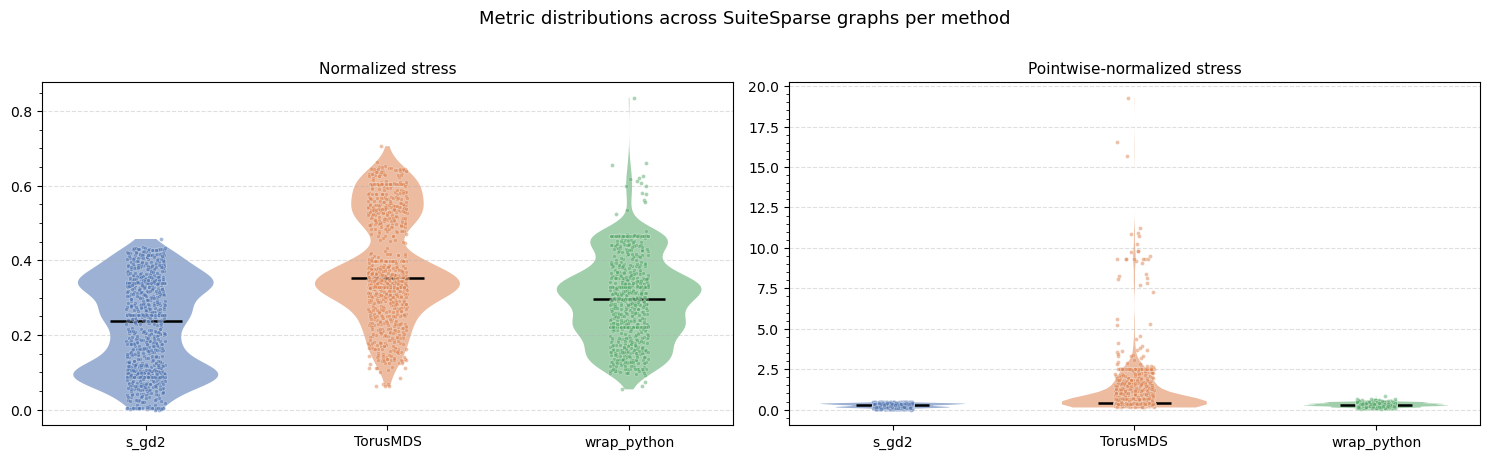

In [ ]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

for ax, metric in zip(axes, METRICS):
    parts = ax.violinplot(
        [data[m][metric].dropna().values for m in METHODS],
        positions=range(len(METHODS)),
        widths=0.6,
        showmedians=True,
        showextrema=False,
    )
    for pc, m in zip(parts['bodies'], METHODS):
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.8)

    for xi, m in enumerate(METHODS):
        vals = data[m][metric].dropna().values
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(xi + jitter, vals, s=8, color=COLORS[m],
                   edgecolors='white', linewidths=0.3, zorder=3, alpha=0.5)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.4)
    ax.set_ylim(0,2.5)

fig.suptitle('Metric distributions across SuiteSparse graphs per method', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig('./results/suitesparse_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Metrics vs graph size n

Note: `wrap_python` is capped at `--wrap-python-max-n` (graphs above that size were skipped during embedding), so its trend line stops early -- that's expected, not missing data.

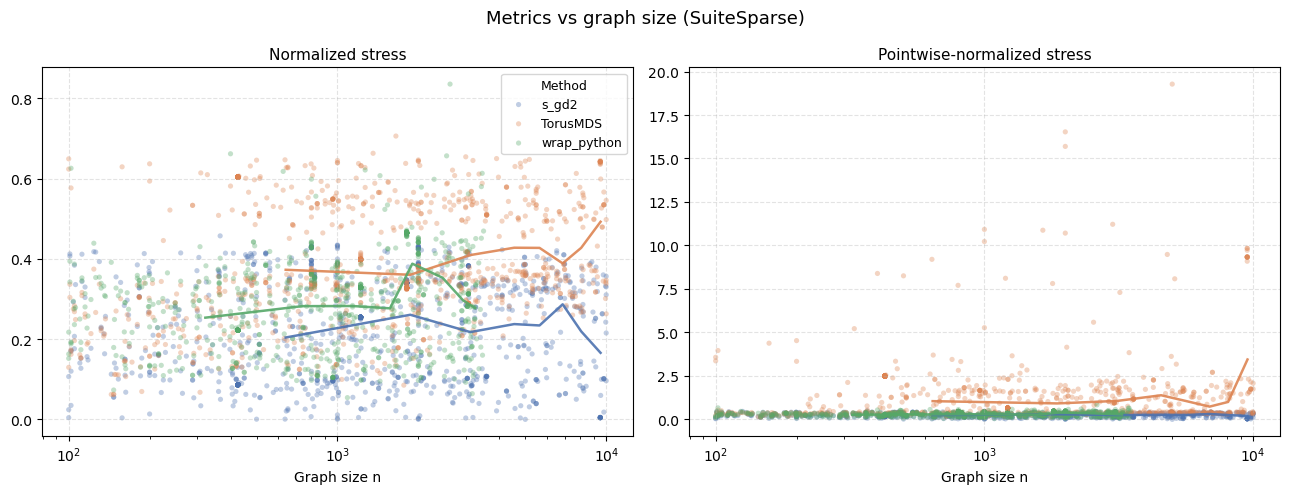

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, METRICS):
    for m in METHODS:
        d = data[m].sort_values('n')
        ax.scatter(d['n'], d[metric], s=14, color=COLORS[m],
                   alpha=0.35, label=m, edgecolors='none')
        bins = pd.cut(d['n'], bins=8)
        trend = d.groupby(bins, observed=True)[metric].mean()
        mids  = d.groupby(bins, observed=True)['n'].mean()
        ax.plot(mids.values, trend.values, color=COLORS[m], linewidth=1.8, alpha=0.9)

    ax.set_xlabel('Graph size n', fontsize=10)
    ax.set_xscale('log')
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(linestyle='--', alpha=0.35)

axes[0].legend(title='Method', fontsize=9, title_fontsize=9)
fig.suptitle('Metrics vs graph size (SuiteSparse)', fontsize=13)
fig.tight_layout()
plt.savefig('./results/suitesparse_metrics_vs_n.png', dpi=150, bbox_inches='tight')
plt.show()


## Running time distributions

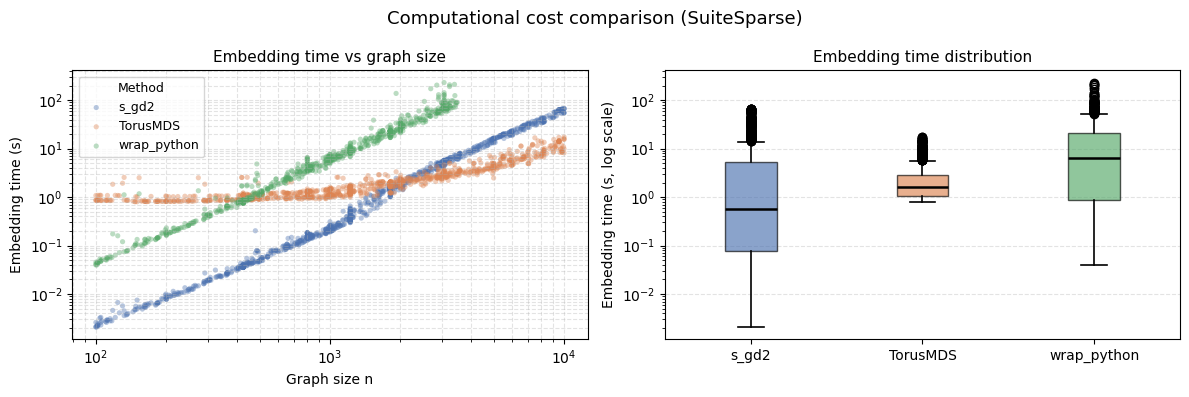

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for m in METHODS:
    d = data[m]
    ax.scatter(d['n'], d['t_embed'], s=14, color=COLORS[m],
               alpha=0.4, label=m, edgecolors='none')
ax.set_xlabel('Graph size n', fontsize=10)
ax.set_ylabel('Embedding time (s)', fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Embedding time vs graph size', fontsize=11)
ax.legend(title='Method', fontsize=9, title_fontsize=9)
ax.grid(linestyle='--', alpha=0.35, which='both')

ax = axes[1]
bp = ax.boxplot(
    [data[m]['t_embed'].values for m in METHODS],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, m in zip(bp['boxes'], METHODS):
    patch.set_facecolor(COLORS[m])
    patch.set_alpha(0.65)
ax.set_yscale('log')
ax.set_xticks(range(1, len(METHODS) + 1))
ax.set_xticklabels(METHODS, fontsize=10)
ax.set_ylabel('Embedding time (s, log scale)', fontsize=10)
ax.set_title('Embedding time distribution', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.yaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))

fig.suptitle('Computational cost comparison (SuiteSparse)', fontsize=13)
fig.tight_layout()
plt.savefig('./results/suitesparse_timing.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary table

In [17]:
summary = df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'median', 'std'])
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.round(4)
summary


,stress_mean,stress_median,stress_std,pointwise_stress_mean,pointwise_stress_median,pointwise_stress_std,t_embed_mean,t_embed_median,t_embed_std
method,,,,,,,,,
TorusMDS,0.3860,0.3519,0.1416,1.1215,0.4098,1.7598,2.7074,1.6488,2.8552
s_gd2,0.2220,0.2370,0.1245,0.2591,0.2780,0.1142,6.7535,0.5811,13.6449
wrap_python,0.2942,0.2960,0.1138,0.3035,0.3009,0.1179,17.8415,6.5385,28.7912


## Performance by SuiteSparse group

Top 10 groups by graph count -- 80 distinct groups total, too many to plot cleanly, so this is a table rather than a chart.

In [18]:
top_groups = df.drop_duplicates('exp_idx')['group'].value_counts().head(10).index
by_group = (
    df[df['group'].isin(top_groups)]
    .groupby(['group', 'method'])[['stress', 'pointwise_stress']]
    .mean()
    .round(4)
)
by_group


stress  pointwise_stress
group        method                               
Bai          TorusMDS     0.4888            3.0638
             s_gd2        0.1023            0.1366
             wrap_python  0.1737            0.1734
DRIVCAV      TorusMDS     0.2888            0.6004
             s_gd2        0.1114            0.1467
             wrap_python  0.2960            0.2485
FIDAP        TorusMDS     0.3714            1.0370
             s_gd2        0.0852            0.1449
             wrap_python  0.2118            0.1962
Gset         TorusMDS     0.3936            0.6850
             s_gd2        0.3768            0.3969
             wrap_python  0.3871            0.4119
HB           TorusMDS     0.3681            0.9486
             s_gd2        0.1751            0.2159
             wrap_python  0.2336            0.2425
ML_Graph     TorusMDS     0.2919            0.8744
             s_gd2        0.2197            0.2656
             wrap_python  0.2694            0.2771
Pajek        TorusMDS     0.3255            0.4057
             s_gd2        0.3034            0.3334
             wrap_python  0.3300            0.3549
Sandia       TorusMDS     0.4350            1.1173
             s_gd2        0.2350            0.2858
             wrap_python  0.3480            0.3559
Schenk_IBMNA TorusMDS     0.3429            0.3796
             s_gd2        0.3402            0.3509
             wrap_python  0.4116            0.4271
VDOL         TorusMDS     0.3151            0.3784
             s_gd2        0.3033            0.3322
             wrap_python  0.3480            0.3624